# Bicycle Codes - Belief Propagation

## Imports

In [17]:
import pickle
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
import stim
import pymatching
import sinter
from typing import List
from ldpc import bposd_decoder, bp_decoder
import importlib, ldpc_decoder
importlib.reload(ldpc_decoder)
from ldpc_decoder import LDPC_Sinter_Decoder

## Circuit Generating Code

In [18]:
def make_bicycle_circuit_d4(rounds: int, noise_prob: float) -> stim.Circuit:
    # Data qubits: 0, 1, 3, 8, 10, 15
    # Ancilla qubits: 16 (measures Z0*Z1*Z3), 17 (measures Z8*Z10*Z15)
    # Stabilizer 0: data qubits [0, 1, 3]  -> ancilla 16
    # Stabilizer 1: data qubits [8, 10, 15] -> ancilla 17
    bitflip_noise = noise_prob
    data_qubits = list(range(0, 16))
    ancilla_0 = 16 
    ancilla_1 = 17 
    ancilla_2 = 18
    ancilla_3 = 19
    ancilla_4 = 20
    ancilla_5 = 21
    ancilla_6 = 22
    ancilla_7 = 23
    
    all_qubits = data_qubits + [ancilla_0, ancilla_1]

    # CX layer
    cx_layer = [
        0, ancilla_0,
        1, ancilla_0,
        3, ancilla_0,
        8, ancilla_0,
        10, ancilla_0,
        15, ancilla_0, # 1 stabiliser
        1, ancilla_1,
        2, ancilla_1,
        4, ancilla_1,
        8, ancilla_1,
        9, ancilla_1,
        11, ancilla_1, # 2 stabiliser
        2, ancilla_2,
        3, ancilla_2,
        5, ancilla_2,
        9, ancilla_2,
        10, ancilla_2,
        12, ancilla_2, # 3 stabiliser
        3, ancilla_3,
        4, ancilla_3,
        6, ancilla_3,
        10, ancilla_3,
        11, ancilla_3,
        13, ancilla_3, # 4 stabiliser
        4, ancilla_4,
        5, ancilla_4,
        7, ancilla_4,
        11, ancilla_4,
        12, ancilla_4,
        14, ancilla_4, # 5 stabiliser
        0, ancilla_5,
        5, ancilla_5,
        6, ancilla_5,
        12, ancilla_5,
        13, ancilla_5,
        15, ancilla_5, # 6 stabiliser
        1, ancilla_6,
        6, ancilla_6,
        7, ancilla_6,
        8, ancilla_6,
        13, ancilla_6,
        14, ancilla_6, # 7 stabiliser
        0, ancilla_7,
        2, ancilla_7,
        7, ancilla_7,
        9, ancilla_7,
        14, ancilla_7,
        15, ancilla_7, # 8 stabiliser
    ]

    c = stim.Circuit()

    # Initialize all qubits
    c.append("R", all_qubits)

    # First round (no comparison to previous measurement)
    c.append("TICK", [])
    c.append("CX", cx_layer)
    c.append("TICK", [])
    c.append("X_ERROR", all_qubits, bitflip_noise)
    c.append("MR", [ancilla_0, ancilla_1, ancilla_2, ancilla_3, ancilla_4, ancilla_5, ancilla_6, ancilla_7])
    c.append("DETECTOR", [stim.target_rec(-8)], [ancilla_0, 0])
    c.append("DETECTOR", [stim.target_rec(-7)], [ancilla_1, 0])
    c.append("DETECTOR", [stim.target_rec(-6)], [ancilla_2, 0])
    c.append("DETECTOR", [stim.target_rec(-5)], [ancilla_3, 0])
    c.append("DETECTOR", [stim.target_rec(-4)], [ancilla_4, 0])
    c.append("DETECTOR", [stim.target_rec(-3)], [ancilla_5, 0])
    c.append("DETECTOR", [stim.target_rec(-2)], [ancilla_6, 0])
    c.append("DETECTOR", [stim.target_rec(-1)], [ancilla_7, 0])

    # Repeated rounds
    repeat_body = stim.Circuit()
    repeat_body.append("TICK", [])
    repeat_body.append("CX", cx_layer)
    repeat_body.append("TICK", [])
    repeat_body.append("X_ERROR", [ancilla_0, ancilla_1, ancilla_2, ancilla_3, ancilla_4, ancilla_5, ancilla_6, ancilla_7], bitflip_noise)
    repeat_body.append("MR", [ancilla_0, ancilla_1, ancilla_2, ancilla_3, ancilla_4, ancilla_5, ancilla_6, ancilla_7])
    repeat_body.append("DETECTOR", [stim.target_rec(-8), stim.target_rec(-16)], [ancilla_0, 0])
    repeat_body.append("DETECTOR", [stim.target_rec(-7), stim.target_rec(-15)], [ancilla_1, 0])
    repeat_body.append("DETECTOR", [stim.target_rec(-6), stim.target_rec(-14)], [ancilla_2, 0])
    repeat_body.append("DETECTOR", [stim.target_rec(-5), stim.target_rec(-13)], [ancilla_3, 0])
    repeat_body.append("DETECTOR", [stim.target_rec(-4), stim.target_rec(-12)], [ancilla_4, 0])
    repeat_body.append("DETECTOR", [stim.target_rec(-3), stim.target_rec(-11)], [ancilla_5, 0])
    repeat_body.append("DETECTOR", [stim.target_rec(-2), stim.target_rec(-10)], [ancilla_6, 0])
    repeat_body.append("DETECTOR", [stim.target_rec(-1), stim.target_rec(-9)], [ancilla_7, 0])

    c.append(stim.CircuitRepeatBlock(rounds - 1, repeat_body))

    # Final data qubit measurements
    c.append("X_ERROR", data_qubits, bitflip_noise)
    c.append("M", data_qubits)


    c.append("DETECTOR",
             [stim.target_rec(-16), stim.target_rec(-15), stim.target_rec(-13),
              stim.target_rec(-8), stim.target_rec(-6), stim.target_rec(-1), stim.target_rec(-24)],
             [ancilla_0, 1])

    c.append("DETECTOR",
             [stim.target_rec(-15), stim.target_rec(-14), stim.target_rec(-12),
              stim.target_rec(-8), stim.target_rec(-7), stim.target_rec(-5), stim.target_rec(-23)],
             [ancilla_1, 1])

    c.append("DETECTOR",
             [stim.target_rec(-14), stim.target_rec(-13), stim.target_rec(-10),
              stim.target_rec(-7), stim.target_rec(-6), stim.target_rec(-4), stim.target_rec(-22)],
             [ancilla_2, 1])

    c.append("DETECTOR",
             [stim.target_rec(-13), stim.target_rec(-12), stim.target_rec(-9),
              stim.target_rec(-6), stim.target_rec(-5), stim.target_rec(-3), stim.target_rec(-21)],
             [ancilla_3, 1])
    
    c.append("DETECTOR",
             [stim.target_rec(-12), stim.target_rec(-11), stim.target_rec(-9),
              stim.target_rec(-5), stim.target_rec(-4), stim.target_rec(-2), stim.target_rec(-20)],
             [ancilla_4, 1])
    
    c.append("DETECTOR",
             [stim.target_rec(-16), stim.target_rec(-11), stim.target_rec(-10),
              stim.target_rec(-4), stim.target_rec(-3), stim.target_rec(-1), stim.target_rec(-19)],
             [ancilla_5, 1])
    
    c.append("DETECTOR",
             [stim.target_rec(-15), stim.target_rec(-10), stim.target_rec(-9),
              stim.target_rec(-8), stim.target_rec(-3), stim.target_rec(-2), stim.target_rec(-18)],
             [ancilla_6, 1])
    
    c.append("DETECTOR",
             [stim.target_rec(-16), stim.target_rec(-14), stim.target_rec(-9),
              stim.target_rec(-7), stim.target_rec(-2), stim.target_rec(-1), stim.target_rec(-17)],
             [ancilla_7, 1])       
         
    # Logical observable: choose a logical operator on data qubits.
    # For this bicycle code a simple choice is qubit 0 (adjust as needed).
    c.append("OBSERVABLE_INCLUDE", [stim.target_rec(i) for i in range(-16, 0)], 0)

    return c



In [19]:
def make_bicycle_circuit_d6(rounds: int, noise_prob: float) -> stim.Circuit:
    bitflip_noise = noise_prob
    data_qubits = list(range(0, 24))
    ancilla = list(range(24, 36))
    
    all_qubits = data_qubits + ancilla

    # CX layer
    cx_layer = [
        0, ancilla[0],
        2, ancilla[0],
        7, ancilla[0],
        12, ancilla[0],
        15, ancilla[0],
        22, ancilla[0], # 1 stabiliser
        1, ancilla[1],
        3, ancilla[1],
        8, ancilla[1],
        13, ancilla[1],
        16, ancilla[1],
        23, ancilla[1], # 2 stabiliser
        2, ancilla[2],
        4, ancilla[2],
        9, ancilla[2],
        12, ancilla[2],
        14, ancilla[2],
        17, ancilla[2], # 3 stabiliser
        3, ancilla[3],
        5, ancilla[3],
        10, ancilla[3],
        13, ancilla[3],
        15, ancilla[3],
        18, ancilla[3], # 4 stabiliser
        4, ancilla[4],
        6, ancilla[4],
        11, ancilla[4],
        14, ancilla[4],
        16, ancilla[4],
        19, ancilla[4], # 5 stabiliser
        0, ancilla[5],
        5, ancilla[5],
        7, ancilla[5],
        15, ancilla[5],
        17, ancilla[5],
        20, ancilla[5], # 6 stabiliser
        1, ancilla[6],
        6, ancilla[6],
        8, ancilla[6],
        16, ancilla[6],
        18, ancilla[6],
        21, ancilla[6], # 7 stabiliser
        2, ancilla[7],
        7, ancilla[7],
        9, ancilla[7],
        17, ancilla[7],
        19, ancilla[7],
        22, ancilla[7], # 8 stabiliser
        3, ancilla[8],
        8, ancilla[8],
        10, ancilla[8],
        18, ancilla[8],
        20, ancilla[8],
        23, ancilla[8], # 9 stabiliser
        4, ancilla[9],
        9, ancilla[9],
        11, ancilla[9],
        12, ancilla[9],
        19, ancilla[9],
        21, ancilla[9], # 10 stabiliser
        0, ancilla[10],
        5, ancilla[10],
        10, ancilla[10],
        13, ancilla[10],
        20, ancilla[10],
        22, ancilla[10], # 11 stabiliser
        1, ancilla[11],
        6, ancilla[11],
        11, ancilla[11],
        14, ancilla[11],
        21, ancilla[11],
        23, ancilla[11], # 12 stabiliser
    ]

    c = stim.Circuit()

    # Initialize all qubits
    c.append("R", all_qubits)

    # First round (no comparison to previous measurement)
    c.append("TICK", [])
    c.append("CX", cx_layer)
    c.append("TICK", [])
    c.append("X_ERROR", all_qubits, bitflip_noise)
    c.append("MR", ancilla)
    c.append("DETECTOR", [stim.target_rec(-12)], [ancilla[0], 0])
    c.append("DETECTOR", [stim.target_rec(-11)], [ancilla[1], 0])
    c.append("DETECTOR", [stim.target_rec(-10)], [ancilla[2], 0])
    c.append("DETECTOR", [stim.target_rec(-9)], [ancilla[3], 0])
    c.append("DETECTOR", [stim.target_rec(-8)], [ancilla[4], 0])
    c.append("DETECTOR", [stim.target_rec(-7)], [ancilla[5], 0])
    c.append("DETECTOR", [stim.target_rec(-6)], [ancilla[6], 0])
    c.append("DETECTOR", [stim.target_rec(-5)], [ancilla[7], 0])
    c.append("DETECTOR", [stim.target_rec(-4)], [ancilla[8], 0])
    c.append("DETECTOR", [stim.target_rec(-3)], [ancilla[9], 0])
    c.append("DETECTOR", [stim.target_rec(-2)], [ancilla[10], 0])
    c.append("DETECTOR", [stim.target_rec(-1)], [ancilla[11], 0])

    # Repeated rounds
    repeat_body = stim.Circuit()
    repeat_body.append("TICK", [])
    repeat_body.append("CX", cx_layer)
    repeat_body.append("TICK", [])
    repeat_body.append("X_ERROR", ancilla, bitflip_noise)
    repeat_body.append("MR", ancilla)
    repeat_body.append("DETECTOR", [stim.target_rec(-12), stim.target_rec(-24)], [ancilla[0], 0])
    repeat_body.append("DETECTOR", [stim.target_rec(-11), stim.target_rec(-23)], [ancilla[1], 0])
    repeat_body.append("DETECTOR", [stim.target_rec(-10), stim.target_rec(-22)], [ancilla[2], 0])
    repeat_body.append("DETECTOR", [stim.target_rec(-9), stim.target_rec(-21)], [ancilla[3], 0])
    repeat_body.append("DETECTOR", [stim.target_rec(-8), stim.target_rec(-20)], [ancilla[4], 0])
    repeat_body.append("DETECTOR", [stim.target_rec(-7), stim.target_rec(-19)], [ancilla[5], 0])
    repeat_body.append("DETECTOR", [stim.target_rec(-6), stim.target_rec(-18)], [ancilla[6], 0])
    repeat_body.append("DETECTOR", [stim.target_rec(-5), stim.target_rec(-17)], [ancilla[7], 0])
    repeat_body.append("DETECTOR", [stim.target_rec(-4), stim.target_rec(-16)], [ancilla[8], 0])
    repeat_body.append("DETECTOR", [stim.target_rec(-3), stim.target_rec(-15)], [ancilla[9], 0])
    repeat_body.append("DETECTOR", [stim.target_rec(-2), stim.target_rec(-14)], [ancilla[10], 0])
    repeat_body.append("DETECTOR", [stim.target_rec(-1), stim.target_rec(-13)], [ancilla[11], 0])

    c.append(stim.CircuitRepeatBlock(rounds - 1, repeat_body))

    # Final data qubit measurements
    c.append("X_ERROR", data_qubits, bitflip_noise)
    c.append("M", data_qubits)


    c.append("DETECTOR",
             [stim.target_rec(-24), stim.target_rec(-22), stim.target_rec(-17),
              stim.target_rec(-12), stim.target_rec(-9), stim.target_rec(-2), stim.target_rec(-36)],
             [ancilla[0], 1])

    c.append("DETECTOR",
             [stim.target_rec(-23), stim.target_rec(-21), stim.target_rec(-16),
              stim.target_rec(-11), stim.target_rec(-8), stim.target_rec(-1), stim.target_rec(-35)],
             [ancilla[1], 1])

    c.append("DETECTOR",
             [stim.target_rec(-22), stim.target_rec(-20), stim.target_rec(-15),
              stim.target_rec(-12), stim.target_rec(-10), stim.target_rec(-7), stim.target_rec(-34)],
             [ancilla[2], 1])

    c.append("DETECTOR",
             [stim.target_rec(-21), stim.target_rec(-19), stim.target_rec(-14),
              stim.target_rec(-11), stim.target_rec(-9), stim.target_rec(-6), stim.target_rec(-33)],
             [ancilla[3], 1])
    
    c.append("DETECTOR",
             [stim.target_rec(-20), stim.target_rec(-18), stim.target_rec(-13),
              stim.target_rec(-10), stim.target_rec(-8), stim.target_rec(-5), stim.target_rec(-32)],
             [ancilla[4], 1])
    
    c.append("DETECTOR",
             [stim.target_rec(-24), stim.target_rec(-19), stim.target_rec(-17),
              stim.target_rec(-9), stim.target_rec(-7), stim.target_rec(-4), stim.target_rec(-31)],
             [ancilla[5], 1])
    
    c.append("DETECTOR",
             [stim.target_rec(-23), stim.target_rec(-18), stim.target_rec(-16),
              stim.target_rec(-8), stim.target_rec(-6), stim.target_rec(-3), stim.target_rec(-30)],
             [ancilla[6], 1])
    
    c.append("DETECTOR",
             [stim.target_rec(-22), stim.target_rec(-17), stim.target_rec(-15),
              stim.target_rec(-7), stim.target_rec(-5), stim.target_rec(-2), stim.target_rec(-29)],
             [ancilla[7], 1])       

    c.append("DETECTOR",
             [stim.target_rec(-21), stim.target_rec(-16), stim.target_rec(-14),
              stim.target_rec(-6), stim.target_rec(-4), stim.target_rec(-1), stim.target_rec(-28)],
             [ancilla[8], 1])
    
    c.append("DETECTOR",
             [stim.target_rec(-20), stim.target_rec(-15), stim.target_rec(-13),
              stim.target_rec(-12), stim.target_rec(-5), stim.target_rec(-3), stim.target_rec(-27)],
             [ancilla[9], 1])
    
    c.append("DETECTOR",
             [stim.target_rec(-24), stim.target_rec(-19), stim.target_rec(-14),
              stim.target_rec(-11), stim.target_rec(-4), stim.target_rec(-2), stim.target_rec(-26)],
             [ancilla[10], 1])
    
    c.append("DETECTOR",
             [stim.target_rec(-23), stim.target_rec(-18), stim.target_rec(-13),
              stim.target_rec(-10), stim.target_rec(-3), stim.target_rec(-1), stim.target_rec(-25)],
             [ancilla[11], 1]) 
    
    # Logical observable: choose a logical operator on data qubits.
    # For this bicycle code a simple choice is qubit 0 (adjust as needed).
    # c.append("OBSERVABLE_INCLUDE", [stim.target_rec(i) for i in range(-24, 0)], 0)
    logical_support = list(range(12, 24))

    c.append(
        "OBSERVABLE_INCLUDE",
        [stim.target_rec(-24 + q) for q in logical_support],
        0
    )

    return c



In [20]:
def generate_qec_circuit(distance: int, rounds: int, noise_prob: float) -> stim.Circuit:
    if distance == 4:
        c = make_bicycle_circuit_d4(rounds= rounds, noise_prob= noise_prob)
    elif distance == 6:
        c = make_bicycle_circuit_d6(rounds= rounds, noise_prob= noise_prob)
        
        
    return c


# Example usage
# print(circuit)

In [21]:
def generate_code_bit_flips(d, noise):
    # SOLUTION ===
    circuit = generate_qec_circuit(
    distance=d,
    rounds=3*d,
    noise_prob=noise)
    # ===
    return circuit

In [22]:
# circuit = generate_code_bit_flips(6,0.1)
# print(circuit)

In [23]:
# You can choose pymatching or vacuous(does nothing), but for other see later
# decoder = ['pymatching']

In [24]:
# circuit.diagram('timeline-svg')

## Threshold

In [25]:
logical_qubits = {4: 6, 6: 12}
qec_code_tasks = [
    sinter.Task(
        circuit=generate_code_bit_flips(d, noise),
        json_metadata={'d': d, 'r': d, 'p': noise, 'k': logical_qubits[d]},
    )
    for d in [4, 6]
    for noise in [1e-8,1e-7,1e-6,1e-5,1e-4, 1e-3, 1e-2, 1e-1]
]

# Use this if decoder is pymatching or vacuous
# collected_stats: List[sinter.TaskStats] = sinter.collect(
#     num_workers=1,
#     tasks=qec_code_tasks,
#     decoders=decoder,
#     max_shots=10**5,
#     max_errors= 500
# )

# If custom decoder(bp ones) use this

custom_decoders = {
    "bposd_0": LDPC_Sinter_Decoder(osd_order=0),
    "bposd_7": LDPC_Sinter_Decoder(osd_order=7),
}

collected_stats: List[sinter.TaskStats] = sinter.collect(
    num_workers=6,
    tasks=qec_code_tasks,
    decoders=["bposd_0"],
    custom_decoders=custom_decoders,
    max_shots=10**7,
    max_errors=1000,
)

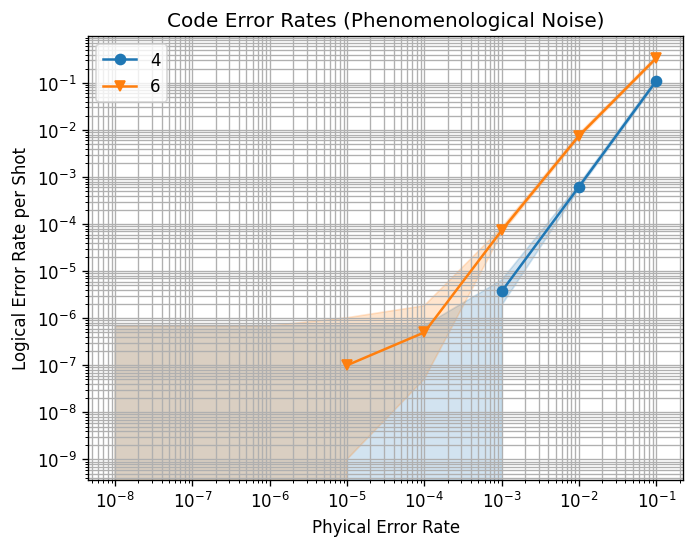

In [26]:
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=collected_stats,
    x_func=lambda stats: stats.json_metadata['p'],
    group_func=lambda stats: stats.json_metadata['d'],
)

ax.loglog()
ax.set_title("Code Error Rates (Phenomenological Noise)")
ax.set_xlabel("Phyical Error Rate")
ax.set_ylabel("Logical Error Rate per Shot")
ax.grid(which='major')
ax.grid(which='minor')
ax.legend()
fig.set_dpi(120)  # Show it bigger

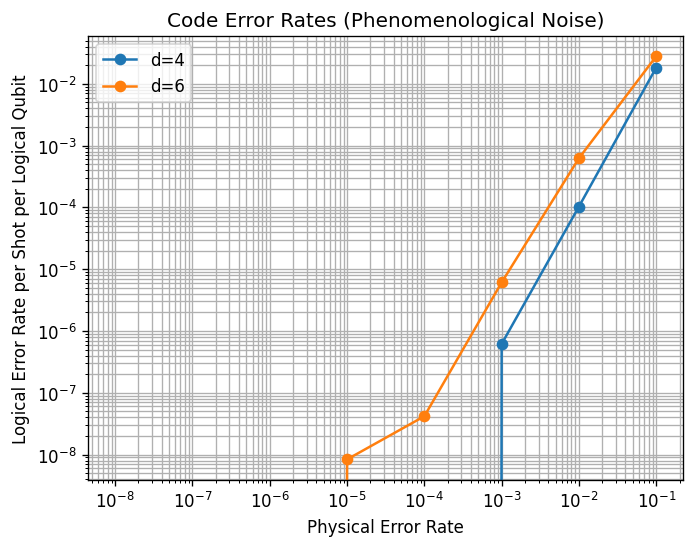

In [27]:
import itertools
import numpy as np

fig, ax = plt.subplots(1, 1)

# Group stats by d
groups = {}
for stat in collected_stats:
    d = stat.json_metadata['d']
    if d not in groups:
        groups[d] = []
    groups[d].append(stat)

for d, stats_list in sorted(groups.items()):
    k = {4: 6, 6: 12}[d]
    # Sort by noise
    stats_list.sort(key=lambda s: s.json_metadata['p'])
    xs = [s.json_metadata['p'] for s in stats_list]
    ys = [s.errors / (s.shots * k) for s in stats_list]
    ax.plot(xs, ys, marker='o', label=f'd={d}')

ax.loglog()
ax.set_title("Code Error Rates (Phenomenological Noise)")
ax.set_xlabel("Physical Error Rate")
ax.set_ylabel("Logical Error Rate per Shot per Logical Qubit")
ax.grid(which='major')
ax.grid(which='minor')
ax.legend()
fig.set_dpi(120)

In [28]:
print([s.errors for s in collected_stats])

[37, 0, 0, 0, 0, 0, 1001, 1047, 0, 0, 0, 1, 5, 733, 1213, 1040]


## Resources Required to reach $10^{-10}$ bit flip error

In [29]:
bit_flip_prob = 0.01
noise_bias = 1e8
goal_logical_error_rate = bit_flip_prob/noise_bias


# SOLUTION ===

tasks = [
    sinter.Task(
        circuit=generate_code_bit_flips(d, noise),
        json_metadata={'d': d, 'p': noise},
    )
    for d in [4,6]
    for noise in [bit_flip_prob]
]

# # Use this if decoder is pymatching or vacuous
# collected_stats: List[sinter.TaskStats] = sinter.collect(
#     num_workers=4,
#     tasks=tasks,
#     decoders=decoder,
#     max_shots=10**7,
#     max_errors=1000,
# )

# If custom decoder use this

custom_decoders = {
    "bposd_0": LDPC_Sinter_Decoder(osd_order=0),
    "bposd_7": LDPC_Sinter_Decoder(osd_order=7),
}

collected_stats: List[sinter.TaskStats] = sinter.collect(
    num_workers=4,
    tasks=tasks,
    decoders=["bposd_0"],
    custom_decoders=custom_decoders,
    max_shots=10**6,
    max_errors=1000,
)

In [30]:
print([s.errors for s in collected_stats])
# If there are no zeros then continue else increase max shots or take only 3 and 5.

[1123, 563]


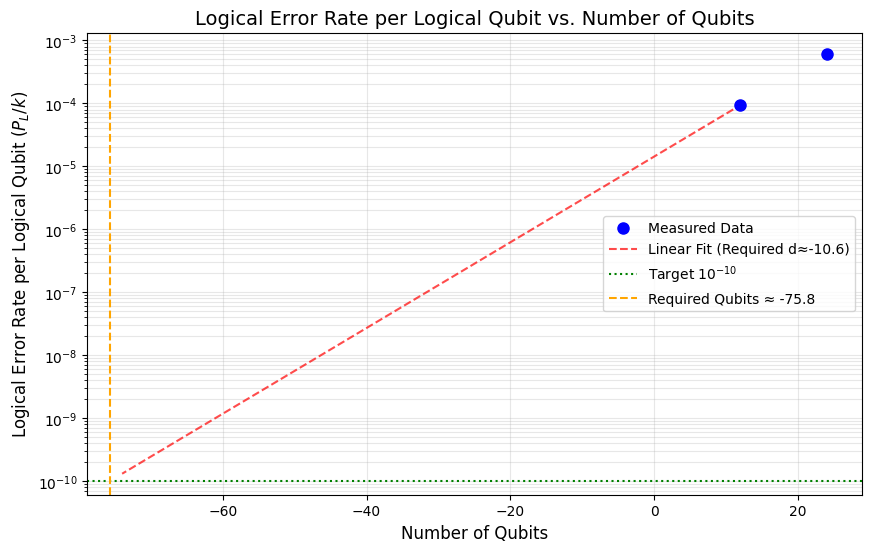

To reach 1e-10 per logical qubit, you need d=-10 (-75 qubits).


In [33]:
logical_qubits = {4: 6, 6: 12}
qubit_map = {4: 12, 6: 24}

data = []
for s in collected_stats:
    if s.errors > 0:
        d = s.json_metadata['d']
        k = logical_qubits[d]
        p_logical = s.errors / (s.shots * k)  # divided by k
        data.append((d, p_logical))

data.sort()
distances = np.array([d for d, p in data])
p_logical = np.array([p for d, p in data])

log_p = np.log10(p_logical)
slope_d, intercept, _, _, _ = linregress(distances, log_p)

target_p = 1e-10
required_d = (np.log10(target_p) - intercept) / slope_d

d_to_q = lambda d: 6 * d - 12
required_qubits = d_to_q(required_d)

fig, ax = plt.subplots(figsize=(10, 6))

qubits = np.array([qubit_map[d] for d in distances])
ax.semilogy(qubits, p_logical, 'bo', label='Measured Data', markersize=8)

q_range = np.linspace(min(qubits) - 1, np.ceil(required_qubits) + 1, 100)
d_range = (q_range + 12) / 6
p_range = 10**(slope_d * d_range + intercept)
ax.semilogy(q_range, p_range, 'r--', alpha=0.7, label=f'Linear Fit (Required d≈{required_d:.1f})')

ax.axhline(target_p, color='green', linestyle=':', label='Target $10^{-10}$')
ax.axvline(required_qubits, color='orange', linestyle='--', label=f'Required Qubits ≈ {required_qubits:.1f}')

ax.set_title('Logical Error Rate per Logical Qubit vs. Number of Qubits', fontsize=14)
ax.set_xlabel('Number of Qubits', fontsize=12)
ax.set_ylabel('Logical Error Rate per Logical Qubit ($P_L / k$)', fontsize=12)
ax.grid(True, which="both", ls="-", alpha=0.3)
ax.legend()

plt.show()

print(f"To reach 1e-10 per logical qubit, you need d={int(np.ceil(required_d))} ({int(np.ceil(required_qubits))} qubits).")

# Save data (Don't forget to update file name)

In [32]:


folder_name = "results"
if not os.path.exists(folder_name):
    os.makedirs(folder_name)
    print(f"Created directory: {folder_name}")
    
# 1. Process your results into a simple dictionary of lists
results_to_store = {
    "distances": [s.json_metadata['d'] for s in collected_stats],
    "qubits": [2 * s.json_metadata['d'] - 1 for s in collected_stats],
    "logical_errors": [s.errors / s.shots for s in collected_stats],
    "raw_errors": [s.errors for s in collected_stats],
    "shots": [s.shots for s in collected_stats]
}

# 2. Perform the extrapolation to include in the file
fit_d = np.array([d for d, e in zip(results_to_store["distances"], results_to_store["raw_errors"]) if e > 0])
fit_p = np.array([p for p, e in zip(results_to_store["logical_errors"], results_to_store["raw_errors"]) if e > 0])

slope, intercept, _, _, _ = linregress(fit_d, np.log10(fit_p))
req_d = (np.log10(1e-10) - intercept) / slope
results_to_store["required_d_1e10"] = req_d
results_to_store["required_qubits_1e10"] = 2 * req_d - 1

# 3. Save using Pickle
file_path = os.path.join(folder_name, 'bicycle_bp.pkl') 
with open(file_path, 'wb') as f:
    pickle.dump(results_to_store, f)

print(f"Data stored in {file_path}")


Data stored in results/bicycle_bp.pkl
